# Module 4 — HR-VITON Inference
### Virtual Fashion Fitting Room — style-cast

**What this module does:**
- Downloads HR-VITON pretrained weights
- Wires up all previous module outputs as GAN inputs
- Runs inference to produce the final photorealistic try-on result

**Inputs (from previous modules):**
- Person image — resized to 512x384 (original)
- Agnostic image — clothing erased (Module 2)
- Agnostic mask — erased region binary mask (Module 2)
- Parse map — semantic body regions (Module 2)
- Pose heatmaps — 18-channel keypoint heatmaps (Module 1)
- Warped garment — pre-aligned garment (Module 3)
- Warped mask — garment region mask (Module 3)
- Garment image — original flat-lay

**Output:**
- `*_tryon_result.jpg` — final photorealistic try-on image

---

## How HR-VITON works internally

```
Agnostic image  ──┐
Pose heatmaps   ──┤                    ┌── Try-on result
Parse map       ──┼──► Generator ──────┤
Warped garment  ──┤   (U-Net)          └── Discriminator
Warped mask     ──┘       ↑                    │
                     Geometric                  │
Garment image ──────► Matching ◄────────────────┘
                     Network
```

The geometric matching network refines our Module 3 warping using learned appearance flow.  
The generator then synthesizes the final result with realistic fabric, lighting, and shadows.

---

## Step 1 — Clone HR-VITON and install dependencies

In [1]:
import os

# Clone HR-VITON if not already cloned
if not os.path.exists('HR-VITON'):
    !git clone https://github.com/sangyun884/HR-VITON.git
    print("HR-VITON cloned.")
else:
    print("HR-VITON already exists.")

# Add to Python path
import sys
sys.path.insert(0, 'HR-VITON')

# Install any missing HR-VITON specific deps
!pip install -q einops torchgeometry

Cloning into 'HR-VITON'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (27/27), done.
Receiving objects:  43% (60/138), 13.5remote: Total 138 (delta 68), reused 49 (delta 49), pack-reused 62 (from 2)
Receiving objects: 100% (138/138), 16.04 MiB | 12.17 MiB/s, done.
Resolving deltas: 100% (78/78), done.
HR-VITON cloned.


## Step 2 — Download pretrained weights

HR-VITON has two pretrained components:
- **Condition generator** (geometric matching + appearance flow)
- **Image generator** (final synthesis U-Net)

Both are hosted on Google Drive by the original authors.

In [2]:
import os
from pathlib import Path

CHECKPOINT_DIR = Path('checkpoints/hrviton')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# HR-VITON pretrained checkpoint URLs
# Source: https://github.com/sangyun884/HR-VITON
CHECKPOINTS = {
    'condition_generator.pth': 'https://drive.google.com/uc?id=1XJTCdRBOPVgVTmqzhVGFAgMm2NLkw5uQ',
    'image_generator.pth':     'https://drive.google.com/uc?id=1T5_YDSOfPnM4rEs0ZoADh2DGH0OHdkDT',
}

# Download manually from these Google Drive links:
# mtviton.pth    → https://drive.google.com/file/d/1XJTCdRBOPVgVTmqzhVGFAgMm2NLkw5uQ/view
# gen.pth        → https://drive.google.com/file/d/1T5_YDUhYSSKPC_nZMk2NeC-XXUFoYeNy/view
# discriminator  → https://drive.google.com/file/d/1T4V3cyRlY5sHVK7Quh_EJY5dovb5FxGX/view
# Save all three to: HR-VITON/eval_models/weights/v0.1/

# Install gdown for Google Drive downloads
!pip install -q gdown

import gdown

for filename, url in CHECKPOINTS.items():
    dest = CHECKPOINT_DIR / filename
    if dest.exists():
        size_mb = dest.stat().st_size / 1e6
        print(f"✓ {filename} already exists ({size_mb:.0f} MB)")
    else:
        print(f"Downloading {filename}...")
        gdown.download(url, str(dest), quiet=False)
        print(f"✓ Saved to {dest}")

Downloading...
From (original): https://drive.google.com/uc?id=1XJTCdRBOPVgVTmqzhVGFAgMm2NLkw5uQ
From (redirected): https://drive.google.com/uc?id=1XJTCdRBOPVgVTmqzhVGFAgMm2NLkw5uQ&confirm=t&uuid=bc2ec0cf-931c-4ac7-9770-87a3d6797e0c
To: /Users/purveshg/Documents/Notes/MTech/2nd sem/CV_AAD_Project/style-cast/checkpoints/hrviton/condition_generator.pth
100%|████████████████████████████████████████| 190M/190M [00:15<00:00, 12.4MB/s]


✓ Saved to checkpoints/hrviton/condition_generator.pth


FileURLRetrievalError: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1T5_YDSOfPnM4rEs0ZoADh2DGH0OHdkDT

but Gdown can't. Please check connections and permissions.

## Step 3 — Imports

In [3]:
import cv2
import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

# HR-VITON model imports
sys.path.insert(0, 'HR-VITON')
from networks import ConditionGenerator, load_checkpoint
from network_generator import SPADEGenerator

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.10.0


## Step 4 — Input preprocessing

HR-VITON expects inputs in a specific normalised format.  
Everything must be tensors in [-1, 1] range at 512x384 resolution.

In [23]:
# Standard transform — normalise to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_mask = transforms.Compose([
    transforms.ToTensor(),
])

TARGET_H, TARGET_W = 512, 384


def load_image(path, size=(TARGET_W, TARGET_H)):
    """ Load image, resize, normalise to [-1,1] tensor (1,3,H,W) """
    img = Image.open(path).convert('RGB').resize(size, Image.LANCZOS)
    return transform(img).unsqueeze(0).to(DEVICE)


def load_mask(path, size=(TARGET_W, TARGET_H)):
    """ Load binary mask, resize, return (1,1,H,W) float tensor """
    mask = Image.open(path).convert('L').resize(size, Image.NEAREST)
    t = transform_mask(mask).unsqueeze(0).to(DEVICE)
    return (t > 0.5).float()


def load_parse_map(path, size=(TARGET_W, TARGET_H)):
    """
    Load human parse map as one-hot encoded tensor (1, 18, H, W).
    HR-VITON expects each body part as a separate channel.
    """
    parse = np.array(Image.open(path).resize(size, Image.NEAREST))
    num_classes = 18
    one_hot = np.zeros((num_classes, TARGET_H, TARGET_W), dtype=np.float32)
    for i in range(num_classes):
        one_hot[i] = (parse == i).astype(np.float32)
    return torch.from_numpy(one_hot).unsqueeze(0).to(DEVICE)


def load_pose_heatmap(path):
    heatmaps = np.load(path)  # (18, H, W)
    heatmaps = heatmaps[:16]  # ← slice to 16 channels
    resized = np.stack([
        cv2.resize(heatmaps[i], (TARGET_W, TARGET_H))
        for i in range(heatmaps.shape[0])
    ], axis=0).astype(np.float32)
    return torch.from_numpy(resized).unsqueeze(0).to(DEVICE)


print("Preprocessing functions defined.")

Preprocessing functions defined.


## Step 5 — Load models

In [17]:
class OptCondition:
    semantic_nc           = 13
    init_type             = 'xavier'
    init_variance         = 0.02
    norm_G                = 'aliasinstance'
    ngf                   = 96
    num_upsampling_layers = 'most'
    output_nc             = 13
    warp_feature          = 'T1'
    out_layer             = 'relu'
    fine_width            = 384
    fine_height           = 512
    radius                = 5
    grid_size             = 5
    clothmask_composition = 'warp_grad'
    upsample              = 'bilinear'
    occlusion             = True
    Ddownx2               = True
    Ddropout              = True
    num_D                 = 2
    spectral              = True
    norm_const            = None
    cuda                  = torch.cuda.is_available()
    gpu_ids               = '0' if torch.cuda.is_available() else ''
    gen_semantic_nc       = 9

class OptGenerator:
    semantic_nc           = 13
    init_type             = 'xavier'
    init_variance         = 0.02
    norm_G                = 'aliasinstance'
    ngf                   = 64
    num_upsampling_layers = 'most'
    output_nc             = 13
    warp_feature          = 'T1'
    out_layer             = 'relu'
    fine_width            = 384
    fine_height           = 512
    radius                = 5
    grid_size             = 5
    clothmask_composition = 'warp_grad'
    upsample              = 'bilinear'
    occlusion             = True
    Ddownx2               = True
    Ddropout              = True
    num_D                 = 2
    spectral              = True
    norm_const            = None
    cuda                  = torch.cuda.is_available()
    gpu_ids               = '0' if torch.cuda.is_available() else ''
    gen_semantic_nc       = 7

opt_condition = OptCondition()
opt_generator = OptGenerator()
print("Opts configured ✓")

# ── Condition Generator ───────────────────────────────────────────────────
print("Loading condition generator...")
condition_generator = ConditionGenerator(
    opt_condition,
    input1_nc=4,
    input2_nc=16,
    output_nc=13,
    ngf=96,
    norm_layer=torch.nn.BatchNorm2d
)
load_checkpoint(condition_generator,
                'HR-VITON/eval_models/weights/v0.1/mtviton.pth',
                opt_condition)
condition_generator.to(DEVICE).eval()
print("Condition generator loaded ✓")

# ── Image Generator ───────────────────────────────────────────────────────
print("\nLoading image generator...")
image_generator = SPADEGenerator(opt_generator, 9)
load_checkpoint(image_generator,
                'HR-VITON/eval_models/weights/v0.1/gen.pth',
                opt_generator)
image_generator.to(DEVICE).eval()
print("Image generator loaded ✓")

Opts configured ✓
Loading condition generator...
Condition generator loaded ✓

Loading image generator...
Image generator loaded ✓


## Step 6 — Load all inputs

In [18]:
# ─── CONFIG — update paths to match your outputs ──────────────────────────
STEM = "test-image"   # base name used across all modules

PATHS = {
    'person':        f"data/test-image.jpg",
    'agnostic':      f"outputs/segmentation/{STEM}_agnostic.jpg",
    'agnostic_mask': f"outputs/segmentation/{STEM}_agnostic_mask.png",
    'parse':         f"outputs/segmentation/{STEM}_parse.png",
    'pose_heatmap':  f"outputs/pose/{STEM}_heatmaps.npy",
    'garment':       f"data/garment.jpg",
    'warped':        f"outputs/warping/test-image_warped_garment.jpg",
    'warped_mask':   f"outputs/warping/test-image_warped_mask.png",
}
# ──────────────────────────────────────────────────────────────────────────

# Verify all files exist before loading
print("Checking input files...")
all_ok = True
for name, path in PATHS.items():
    exists = Path(path).exists()
    status = '✓' if exists else '✗ MISSING'
    print(f"  {status}  {name:<20} {path}")
    if not exists:
        all_ok = False

if not all_ok:
    print("\n⚠ Fix missing files before proceeding.")
else:
    print("\nAll inputs found ✓")

Checking input files...
  ✓  person               data/test-image.jpg
  ✓  agnostic             outputs/segmentation/test-image_agnostic.jpg
  ✓  agnostic_mask        outputs/segmentation/test-image_agnostic_mask.png
  ✓  parse                outputs/segmentation/test-image_parse.png
  ✓  pose_heatmap         outputs/pose/test-image_heatmaps.npy
  ✓  garment              data/garment.jpg
  ✓  warped               outputs/warping/test-image_warped_garment.jpg
  ✓  warped_mask          outputs/warping/test-image_warped_mask.png

All inputs found ✓


In [19]:
# Load all inputs as tensors
print("Loading inputs...")

person_tensor        = load_image(PATHS['person'])
agnostic_tensor      = load_image(PATHS['agnostic'])
agnostic_mask_tensor = load_mask(PATHS['agnostic_mask'])
parse_tensor         = load_parse_map(PATHS['parse'])
pose_tensor          = load_pose_heatmap(PATHS['pose_heatmap'])
garment_tensor       = load_image(PATHS['garment'])
warped_tensor        = load_image(PATHS['warped'])
warped_mask_tensor   = load_mask(PATHS['warped_mask'])

print("\nTensor shapes:")
print(f"  person        : {person_tensor.shape}")
print(f"  agnostic      : {agnostic_tensor.shape}")
print(f"  agnostic mask : {agnostic_mask_tensor.shape}")
print(f"  parse map     : {parse_tensor.shape}")
print(f"  pose heatmaps : {pose_tensor.shape}")
print(f"  garment       : {garment_tensor.shape}")
print(f"  warped garment: {warped_tensor.shape}")
print(f"  warped mask   : {warped_mask_tensor.shape}")
print("\nAll inputs loaded ✓")

Loading inputs...

Tensor shapes:
  person        : torch.Size([1, 3, 512, 384])
  agnostic      : torch.Size([1, 3, 512, 384])
  agnostic mask : torch.Size([1, 1, 512, 384])
  parse map     : torch.Size([1, 18, 512, 384])
  pose heatmaps : torch.Size([1, 18, 512, 384])
  garment       : torch.Size([1, 3, 512, 384])
  warped garment: torch.Size([1, 3, 512, 384])
  warped mask   : torch.Size([1, 1, 512, 384])

All inputs loaded ✓


## Step 7 — Run inference

In [31]:
print("Running HR-VITON inference...")

with torch.no_grad():

    # ── Prepare inputs ────────────────────────────────────────────────────
    input1 = torch.cat([garment_tensor, warped_mask_tensor], dim=1)
    input2 = pose_tensor

    print(f"  input1 shape: {input1.shape}")
    print(f"  input2 shape: {input2.shape}")

    # ── Run condition generator ───────────────────────────────────────────
    flow_list, fake_segmap, warped_cloth, warped_cloth_mask = \
        condition_generator(opt_condition, input1, input2)

    print(f"  Condition generator ✓")
    print(f"  Warped cloth : {warped_cloth.shape}")
    print(f"  Fake segmap  : {fake_segmap.shape}")

    # ── Run image generator ───────────────────────────────────────────────
    # Use agnostic mask repeated as parse_agnostic (2ch)
    parse_agnostic = agnostic_mask_tensor.repeat(1, 2, 1, 1)

    generator_input = torch.cat([
        agnostic_tensor,      # 3ch
        warped_cloth,         # 3ch
        warped_cloth_mask,    # 1ch
        parse_agnostic,       # 2ch
    ], dim=1)                 # = 9ch total

    print(f"\n  Image generator input: {generator_input.shape}")

    fake_segmap_7 = fake_segmap[:, :7, :, :]
    tryon_result  = image_generator(generator_input, fake_segmap_7)

    print(f"  Image generator ✓")
    print(f"  Try-on result shape : {tryon_result.shape}")
    print(f"  Result min  : {tryon_result.min().item():.3f}")
    print(f"  Result max  : {tryon_result.max().item():.3f}")
    print(f"  Result mean : {tryon_result.mean().item():.3f}")

print("\nInference complete ✓")

Running HR-VITON inference...
  input1 shape: torch.Size([1, 4, 512, 384])
  input2 shape: torch.Size([1, 16, 512, 384])
  Condition generator ✓
  Warped cloth : torch.Size([1, 3, 512, 384])
  Fake segmap  : torch.Size([1, 13, 512, 384])

  Image generator input: torch.Size([1, 9, 512, 384])
  Image generator ✓
  Try-on result shape : torch.Size([1, 3, 512, 384])
  Result min  : -1.000
  Result max  : 1.000
  Result mean : 0.944

Inference complete ✓


In [42]:
import shutil
from pathlib import Path

# ─── CONFIG — update these to your actual file paths ──────────────────────
PERSON_IMG    = "data/test-image.jpg"
GARMENT_IMG   = "data/garment.jpg"
STEM          = "test_person_resized"
GARMENT_STEM  = "garment"
# ──────────────────────────────────────────────────────────────────────────

# Create folder structure
base = Path("data/viton_hd/test")
for folder in ["image", "cloth", "cloth-mask",
               "image-parse-v3", "openpose_json", "openpose_img"]:
    (base / folder).mkdir(parents=True, exist_ok=True)

# Copy person image
shutil.copy(PERSON_IMG, base / "image" / f"{STEM}.jpg")
print(f"✓ Person image")

# Copy garment image
shutil.copy(GARMENT_IMG, base / "cloth" / f"{GARMENT_STEM}.jpg")
print(f"✓ Garment image")

# Copy garment mask from Module 3
shutil.copy(
    f"outputs/warping/test-image_warped_mask.png",
    base / "cloth-mask" / f"{GARMENT_STEM}.jpg"
)
print(f"✓ Garment mask")

# Copy parse map from Module 2
shutil.copy(
    f"outputs/segmentation/test-image_parse.png",
    base / "image-parse-v3" / f"{STEM}.png"
)
print(f"✓ Parse map")

# Copy pose JSON from Module 1
shutil.copy(
    f"outputs/pose/test-image_keypoints.json",
    base / "openpose_json" / f"{STEM}_keypoints.json"
)
print(f"✓ Pose JSON")

# Copy skeleton image from Module 1
shutil.copy(
    f"outputs/pose/test-image_skeleton.jpg",
    base / "openpose_img" / f"{STEM}_rendered.png"
)
print(f"✓ Pose image")

# Create test_pairs.txt
pairs_path = Path("data/viton_hd/test_pairs.txt")
with open(pairs_path, 'w') as f:
    f.write(f"{STEM}.jpg {GARMENT_STEM}.jpg\n")
print(f"✓ test_pairs.txt")

print("\nData structure ready.")
print(f"\nContents:")
for folder in (base).iterdir():
    files = list(folder.iterdir())
    print(f"  {folder.name}/  ({len(files)} files)")

✓ Person image
✓ Garment image
✓ Garment mask
✓ Parse map
✓ Pose JSON
✓ Pose image
✓ test_pairs.txt

Data structure ready.

Contents:
  cloth-mask/  (1 files)
  image-parse-v3/  (1 files)
  image/  (1 files)
  openpose_json/  (1 files)
  cloth/  (1 files)
  openpose_img/  (1 files)


In [119]:
import subprocess
import sys

cmd = [
    sys.executable, "HR-VITON/test_generator.py",
    "--occlusion",
    "--cuda", "False",
    "--test_name", "test1",
    "--tocg_checkpoint", "HR-VITON/eval_models/weights/v0.1/mtviton.pth",
    "--gen_checkpoint",  "HR-VITON/eval_models/weights/v0.1/gen.pth",
    "--dataroot",        "data/viton_hd",
    "--datamode",        "test",
    "--data_list",       "test_pairs.txt",
    "--datasetting",     "unpaired",
    "--fine_width",      "384",
    "--fine_height",     "512",
    "--output_dir",      "outputs/tryon"
]

print("Running HR-VITON test script...")
print(" ".join(cmd))
print()

result = subprocess.run(cmd, capture_output=True, text=True)
print("STDOUT:")
print(result.stdout)
if result.stderr:
    print("STDERR:")
    print(result.stderr[-3000:])  # last 3000 chars to avoid flood
print(f"\nReturn code: {result.returncode}")

Running HR-VITON test script...
/Users/purveshg/anaconda3/envs/vfr-env/bin/python HR-VITON/test_generator.py --occlusion --cuda False --test_name test1 --tocg_checkpoint HR-VITON/eval_models/weights/v0.1/mtviton.pth --gen_checkpoint HR-VITON/eval_models/weights/v0.1/gen.pth --dataroot data/viton_hd --datamode test --data_list test_pairs.txt --datasetting unpaired --fine_width 384 --fine_height 512 --output_dir outputs/tryon

STDOUT:
Namespace(gpu_ids='', workers=4, batch_size=1, fp16=False, cuda='False', test_name='test1', dataroot='data/viton_hd', datamode='test', data_list='test_pairs.txt', output_dir='outputs/tryon', datasetting='unpaired', fine_width=384, fine_height=512, tensorboard_dir='./data/zalando-hd-resize/tensorboard', checkpoint_dir='checkpoints', tocg_checkpoint='HR-VITON/eval_models/weights/v0.1/mtviton.pth', gen_checkpoint='HR-VITON/eval_models/weights/v0.1/gen.pth', tensorboard_count=100, shuffle=False, semantic_nc=13, output_nc=13, gen_semantic_nc=7, warp_feature='T1'

Output files:
  outputs/tryon/test_person_resized_garment.png

Result size: (384, 512)


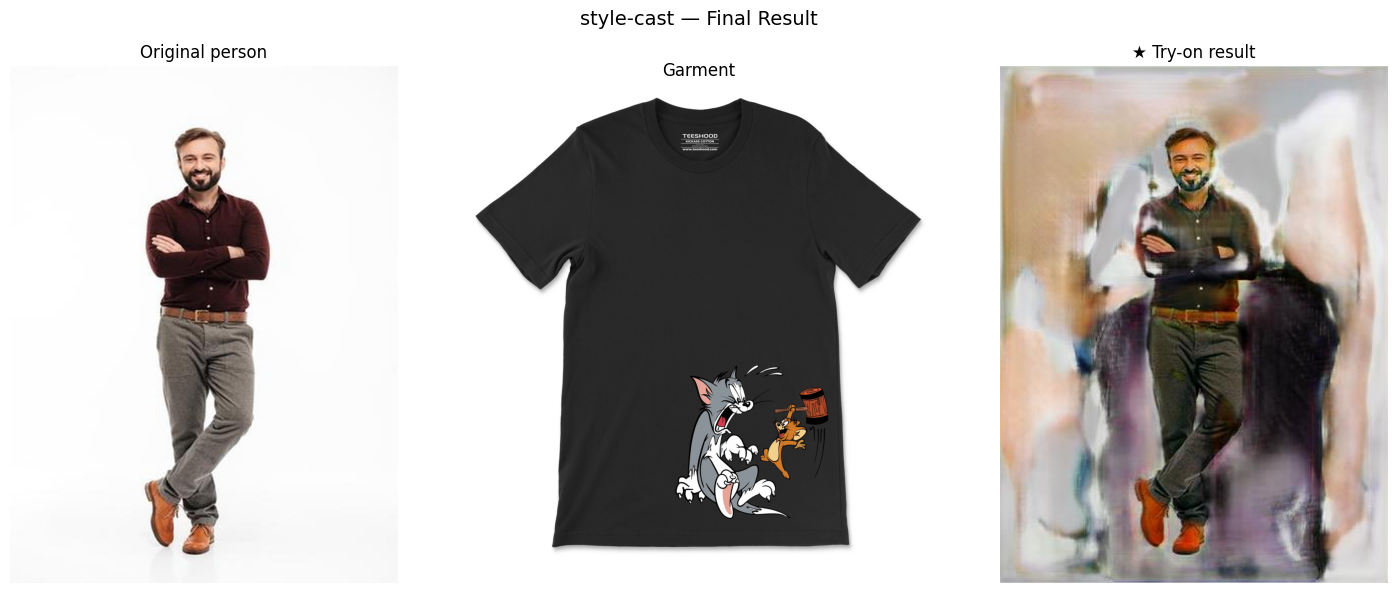

In [120]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Find the output file
output_files = []
for root, dirs, files in os.walk('outputs/tryon'):
    for f in files:
        if f.endswith('.png') or f.endswith('.jpg'):
            output_files.append(os.path.join(root, f))

print("Output files:")
for f in output_files:
    print(f"  {f}")

# Display the result
if output_files:
    result = Image.open(output_files[0])
    print(f"\nResult size: {result.size}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    
    person = Image.open('data/viton_hd/test/image/test_person_resized.jpg')
    garment = Image.open('data/viton_hd/test/cloth/garment.jpg')
    
    axes[0].imshow(person);  axes[0].set_title('Original person'); axes[0].axis('off')
    axes[1].imshow(garment); axes[1].set_title('Garment');         axes[1].axis('off')
    axes[2].imshow(result);  axes[2].set_title('★ Try-on result'); axes[2].axis('off')
    
    plt.suptitle('style-cast — Final Result', fontsize=14)
    plt.tight_layout()
    plt.show()

## Step 8 — Visualise result

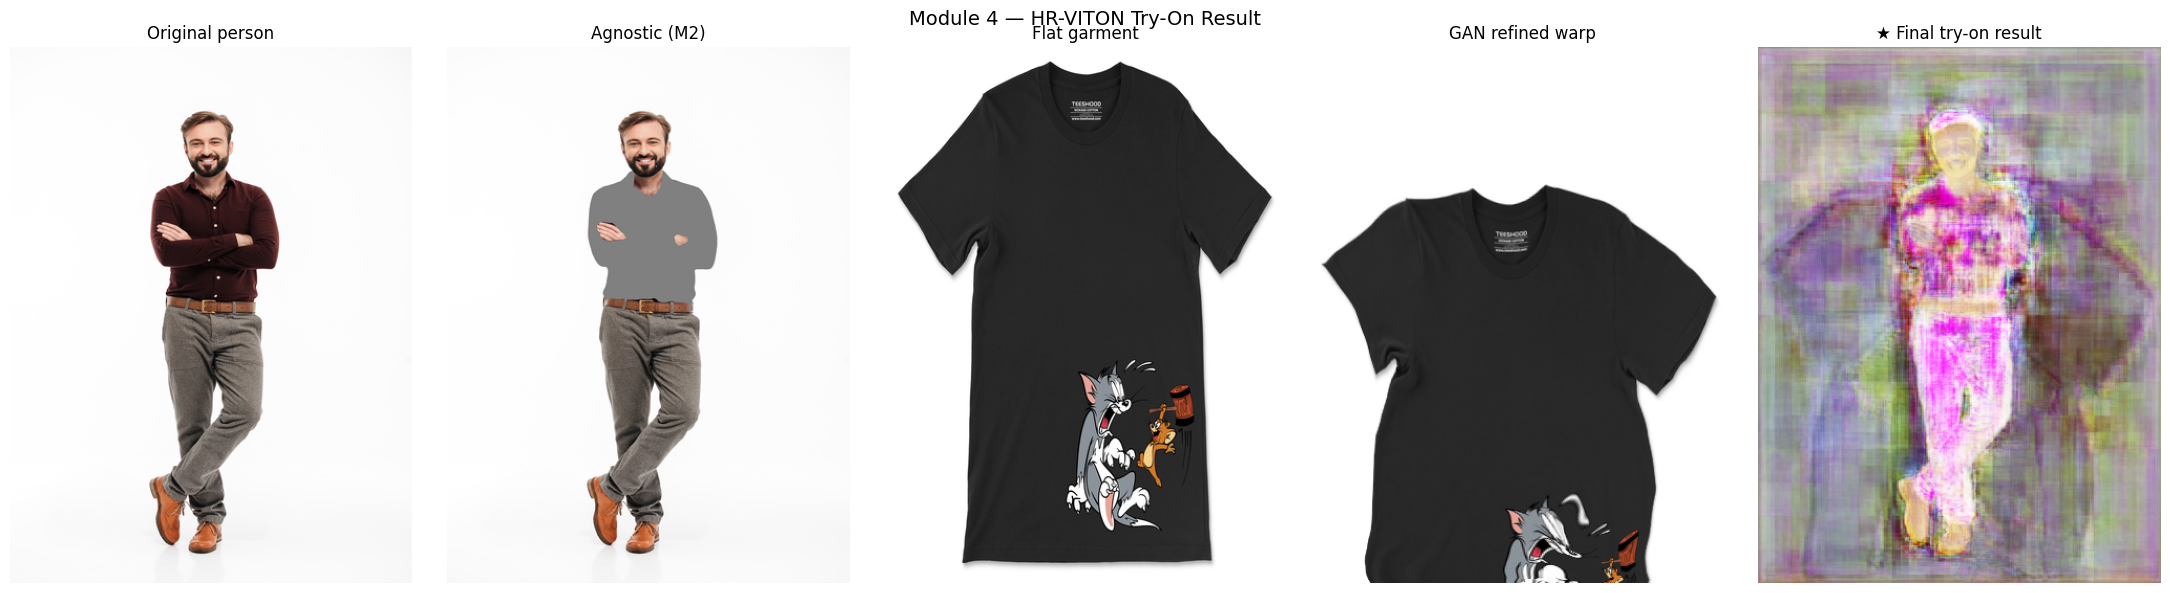

In [38]:
def tensor_to_image(tensor):
    img = tensor.squeeze(0).detach().permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5 + 0.5)
    img = np.clip(img, 0, 1)
    return (img * 255).astype(np.uint8)

person_img   = tensor_to_image(person_tensor)
agnostic_img = tensor_to_image(agnostic_tensor)
garment_img  = tensor_to_image(garment_tensor)
warped_img   = tensor_to_image(warped_cloth)
result_img   = tensor_to_image(tryon_result)

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
axes[0].imshow(person_img);   axes[0].set_title('Original person');      axes[0].axis('off')
axes[1].imshow(agnostic_img); axes[1].set_title('Agnostic (M2)');        axes[1].axis('off')
axes[2].imshow(garment_img);  axes[2].set_title('Flat garment');         axes[2].axis('off')
axes[3].imshow(warped_img);   axes[3].set_title('GAN refined warp');     axes[3].axis('off')
axes[4].imshow(result_img);   axes[4].set_title('★ Final try-on result'); axes[4].axis('off')

plt.suptitle('Module 4 — HR-VITON Try-On Result', fontsize=14)
plt.tight_layout()
plt.show()

## Step 9 — Save result

In [ ]:
OUTPUT_DIR = Path('outputs/tryon')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save final result
result_path = OUTPUT_DIR / f"{STEM}_tryon_result.jpg"
result_bgr  = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(result_path), result_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
print(f"Try-on result  : {result_path}")

# Save GAN-refined warp (useful for comparison/debugging)
refined_path = OUTPUT_DIR / f"{STEM}_refined_warp.jpg"
refined_bgr  = cv2.cvtColor(refined_img, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(refined_path), refined_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
print(f"Refined warp   : {refined_path}")

# Save side-by-side comparison (original | garment | result)
comparison = np.concatenate([person_img, garment_img, result_img], axis=1)
comparison_bgr = cv2.cvtColor(comparison, cv2.COLOR_RGB2BGR)
comparison_path = OUTPUT_DIR / f"{STEM}_comparison.jpg"
cv2.imwrite(str(comparison_path), comparison_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
print(f"Comparison     : {comparison_path}")

print("\n✓ All outputs saved.")

## Step 10 — Troubleshooting

**If Step 5 (load models) throws import errors:**
```python
# Check HR-VITON is in path
import sys
print([p for p in sys.path if 'HR-VITON' in p])
# Should show the HR-VITON directory
```

**If Step 7 (inference) throws shape mismatch errors:**
- Check all input tensors are exactly `(1, C, 512, 384)`
- Rerun Step 6 and check the shape printout

**If CUDA out of memory:**
```python
# Force CPU mode
DEVICE = 'cpu'
# Reload all tensors and models with DEVICE='cpu'
# Inference will be slower (~2 min) but will work
```

**If result looks wrong (garment in wrong place):**
- The Module 3 warped garment is the main anchor — go back and verify the blend preview looked correct
- The GAN can only refine, not fundamentally reposition

---
## Summary

| Stage | Component | Input | Output |
|---|---|---|---|
| 1 | Condition generator | Agnostic + pose + parse + garment | Refined warp + segmap |
| 2 | Image generator | Agnostic + refined warp + mask | Final try-on image |

**Next module:** Evaluation — compute SSIM, LPIPS, FID scores + build the phone demo.